In [1]:
from kan import *



In [2]:
torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
model = KAN(width=[5,5,1], grid=3, k=3, seed=18, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [4]:
import pandas as pd
df = pd.read_csv('RF_csv/all_available(t-1)_with_spatial.csv')
df.columns

Index(['Unnamed: 0', 'Time', 'Station_ID', 'PM2.5', 'Ozone', 'NO2', 'Date',
       'Average_PM2.5_t-1', 'Average_Ozone_t-1', 'Average_NO2_t-1', 'Station',
       'Lat', 'Lon', 'Spatial_Avg_PM2.5', 'Spatial_Avg_Ozone',
       'Spatial_Avg_NO2'],
      dtype='object')

In [5]:
import torch

X = df[['Ozone','NO2','Lat','Lon','Time']]
Y = df['PM2.5']

X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# If X_train is a DataFrame or NumPy array
X_tensor = torch.tensor(X.values)  # Convert to tensor
Y_tensor = torch.tensor(Y.values)  # Convert to tensor

C:\Users\Faculty\AppData\Local\Temp\ipykernel_54388\174919607.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


In [6]:
from sklearn.model_selection import train_test_split

# Split the dataset into train and test (e.g., 80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)  
# Create a dataset dictionary with both train and test data
dataset = {
    'train_input': X_train,
    'train_label': Y_train,
    'test_input': X_test,   # Add test input
    'test_label': Y_test    # Add test labels
}

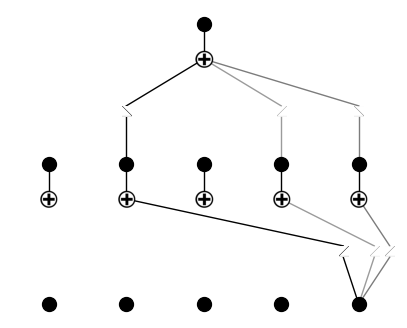

In [7]:

model(dataset['train_input'])
model.plot()

In [8]:
model.fit(dataset, opt='LBFGS', steps=50, lamb=0.001)

description:   0%|                                                           | 0/50 [00:01<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 210.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 2.79 GiB is allocated by PyTorch, and 504.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)